## Hypothesis ##
Historical team performance in La Liga is a strong predictor of future outcomes. Teams that consistently rank in the top four with high point totals, strong goal differences, and favorable win/loss ratios are more likely to win the league in the 2025-26 season.

Conversely, teams that finish near the bottom of the table with negative goal differences are more likely to be relegated, while mid-table clubs with stable performance trends are most likely to qualify for the UEFA Conference League (7th place).

By analyzing past seasons (2010-2026) and the current state of the league table, the model can estimate the realistic probability of each team's finishing position in the La Liga 2025-2026 season.

In [96]:
import pandas as pd

full_data = pd.read_csv("la_liga_data_2010_2026.csv")
print(full_data.shape)
full_data.tail(20)

(300, 22)


,rk,squad,mp,w,d,l,gf,ga,gd,pts,...,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90,games_left,projected_pts
280,1,Barcelona,38,28,4,6,102,39,63,88,...,Robert Lewandowski - 27,Iñaki Peña,→ Champions League via league finish,2024,91.5,41.9,49.5,1.30,0,88.0
281,2,Real Madrid,38,26,6,6,78,38,40,84,...,Kylian Mbappé - 31,Thibaut Courtois,→ Champions League via league finish,2024,75.3,42.8,32.5,0.86,0,84.0
282,3,Atlético Madrid,38,22,10,6,68,30,38,76,...,Alexander Sørloth - 20,Jan Oblak,→ Champions League via league finish,2024,64.6,33.4,31.2,0.82,0,76.0
283,4,Athletic Club,38,19,13,6,54,29,25,70,...,Oihan Sancet - 15,Unai Simón,→ Champions League via league finish,2024,53.0,37.8,15.2,0.40,0,70.0
284,5,Villarreal,38,20,10,8,71,51,20,70,...,Ayoze Pérez - 19,Diego Conde,→ Champions League via league finish,2024,64.8,44.4,20.4,0.54,0,70.0
285,6,Betis,38,16,12,10,57,50,7,60,...,Isco - 9,Adrián,→ Europa League via league finish,2024,54.7,50.6,4.1,0.11,0,60.0
286,7,Celta Vigo,38,16,7,15,59,57,2,55,...,Borja Iglesias - 11,Vicente Guaita,→ Europa League via league finish,2024,54.2,43.4,10.9,0.29,0,55.0
287,8,Rayo Vallecano,38,13,13,12,41,45,-4,52,...,Jorge de Frutos - 6,Augusto Batalla,→ Conference League via league finish,2024,45.4,49.0,-3.5,-0.09,0,52.0
288,9,Osasuna,38,12,16,10,48,52,-4,52,...,Ante Budimir - 21,Sergio Herrera,NaN,2024,44.0,53.7,-9.7,-0.25,0,52.0
289,10,Mallorca,38,13,9,16,35,44,-9,48,...,"Cyle Larin, Vedat Muriqi - 7",Dominik Greif,NaN,2024,38.8,46.8,-8.1,-0.21,0,48.0


## Data Exploration

In [97]:
# Number of appearances for the past 15 seasons
# if below 15 then the team was relegated at some point
full_data['squad'].value_counts()

squad
Barcelona          15
Valencia           15
Sevilla            15
Athletic Club      15
Atlético Madrid    15
Real Madrid        15
Real Sociedad      15
Villarreal         14
Getafe             14
Celta Vigo         13
Betis              13
Espanyol           13
Levante            11
Osasuna            11
Rayo Vallecano     10
Granada            10
Alavés              8
Mallorca            8
Málaga              8
Eibar               7
Valladolid          7
La Coruña           6
Almería             5
Elche               5
Las Palmas          5
Leganés             5
Girona              5
Sporting Gijón      4
Cádiz               4
Zaragoza            3
Racing Sant         2
Huesca              2
Hércules            1
Córdoba             1
Name: count, dtype: int64

In [98]:
# Top 3 ranking count per team
full_data['squad'].groupby(full_data['rk']).value_counts().head(10)

rk  squad          
1   Barcelona          8
    Real Madrid        5
    Atlético Madrid    2
2   Real Madrid        7
    Barcelona          6
    Atlético Madrid    2
3   Atlético Madrid    8
    Real Madrid        3
    Valencia           2
    Barcelona          1
Name: count, dtype: int64

In [99]:
# Count number of times each team finished 1st, 2nd, 3rd in last 10 years
top3_counts = full_data[full_data['season'] < 2024].groupby ('squad')['rk'].apply(lambda x: (x <= 3).sum())

# Normalize to get a historical weight
historical_weight = top3_counts / top3_counts.sum()

In [100]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser" # Opens chart in default browser

# Get the top 3 ranks only
ranking_counts = full_data['squad'].groupby(
    full_data['rk']).value_counts().reset_index(name='count')

# Keep only top 3 ranks
ranking_counts = ranking_counts[ranking_counts['rk'].isin([1, 2, 3])]

# Plot how often each team finished in the top 3 over the last 15 years
fig = px.bar(ranking_counts, x='squad', y='count', color='rk',
             barmode='group',
             title='Top 3 Finished by Team and Rank (Last 15 Years)',
             labels={'squad': 'Team', 'count': 'Finish Count', 'rk': 'Rank'})

fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [101]:
# Shows summary statistics for all numerical columns in dataset
full_data.describe()

,rk,mp,w,d,l,gf,ga,gd,pts,pts/mp,attendance,season,xg,xga,xgd,xgd/90,games_left,projected_pts
count,300.000000,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,204.000000,300.000000,160.00000,160.000000,1.600000e+02,160.000000,300.0,300.000000
mean,10.500000,38.0,14.236667,9.526667,14.236667,50.686667,50.686667,0.000000,52.226667,1.374667,26453.098039,2017.000000,48.84250,48.843750,1.776357e-16,-0.000312,0.0,52.226667
std,5.775916,0.0,6.180722,2.928802,5.422669,18.688840,12.761059,27.460887,17.340828,0.456175,18088.531993,4.327713,11.62082,8.621326,1.712988e+01,0.450948,0.0,17.340828
min,1.000000,38.0,3.000000,2.000000,1.000000,22.000000,18.000000,-64.000000,16.000000,0.420000,91.000000,2010.000000,29.30000,32.500000,-3.300000e+01,-0.870000,0.0,16.000000
25%,5.750000,38.0,10.000000,7.750000,11.000000,38.750000,43.000000,-17.000000,41.000000,1.080000,13677.500000,2013.000000,40.57500,42.875000,-1.100000e+01,-0.290000,0.0,41.000000
50%,10.500000,38.0,13.000000,9.000000,15.000000,46.000000,51.000000,-7.000000,48.000000,1.260000,19957.000000,2017.000000,45.85000,48.300000,-3.150000e+00,-0.080000,0.0,48.000000
75%,15.250000,38.0,17.000000,11.000000,18.000000,58.000000,58.250000,10.250000,60.000000,1.580000,37320.500000,2021.000000,53.97500,54.425000,1.100000e+01,0.292500,0.0,60.000000
max,20.000000,38.0,32.000000,18.000000,30.000000,121.000000,94.000000,89.000000,100.000000,2.630000,83498.000000,2024.000000,91.50000,76.200000,4.950000e+01,1.300000,0.0,100.000000


In [102]:
# Winning teams of the past 15 years

# Filter the dataset for teams that finished 1st each season
winning_teams = full_data[full_data["rk"] == 1][[
    "season", "squad", "pts", "pts/mp", "gd"]].sort_values("season")

# Display the results
print(winning_teams)

     season            squad  pts  pts/mp  gd
0      2010        Barcelona   96    2.53  74
20     2011      Real Madrid  100    2.63  89
40     2012        Barcelona  100    2.63  75
60     2013  Atlético Madrid   90    2.37  51
80     2014        Barcelona   94    2.47  89
100    2015        Barcelona   91    2.39  83
120    2016      Real Madrid   93    2.45  65
140    2017        Barcelona   93    2.45  70
160    2018        Barcelona   87    2.29  54
180    2019      Real Madrid   87    2.29  45
200    2020  Atlético Madrid   86    2.26  42
220    2021      Real Madrid   86    2.26  49
240    2022        Barcelona   88    2.32  50
260    2023      Real Madrid   95    2.50  61
280    2024        Barcelona   88    2.32  63


In [103]:
full_data.tail(20)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,...,top_team_scorer,goalkeeper,notes,season,xg,xga,xgd,xgd/90,games_left,projected_pts
280,1,Barcelona,38,28,4,6,102,39,63,88,...,Robert Lewandowski - 27,Iñaki Peña,→ Champions League via league finish,2024,91.5,41.9,49.5,1.30,0,88.0
281,2,Real Madrid,38,26,6,6,78,38,40,84,...,Kylian Mbappé - 31,Thibaut Courtois,→ Champions League via league finish,2024,75.3,42.8,32.5,0.86,0,84.0
282,3,Atlético Madrid,38,22,10,6,68,30,38,76,...,Alexander Sørloth - 20,Jan Oblak,→ Champions League via league finish,2024,64.6,33.4,31.2,0.82,0,76.0
283,4,Athletic Club,38,19,13,6,54,29,25,70,...,Oihan Sancet - 15,Unai Simón,→ Champions League via league finish,2024,53.0,37.8,15.2,0.40,0,70.0
284,5,Villarreal,38,20,10,8,71,51,20,70,...,Ayoze Pérez - 19,Diego Conde,→ Champions League via league finish,2024,64.8,44.4,20.4,0.54,0,70.0
285,6,Betis,38,16,12,10,57,50,7,60,...,Isco - 9,Adrián,→ Europa League via league finish,2024,54.7,50.6,4.1,0.11,0,60.0
286,7,Celta Vigo,38,16,7,15,59,57,2,55,...,Borja Iglesias - 11,Vicente Guaita,→ Europa League via league finish,2024,54.2,43.4,10.9,0.29,0,55.0
287,8,Rayo Vallecano,38,13,13,12,41,45,-4,52,...,Jorge de Frutos - 6,Augusto Batalla,→ Conference League via league finish,2024,45.4,49.0,-3.5,-0.09,0,52.0
288,9,Osasuna,38,12,16,10,48,52,-4,52,...,Ante Budimir - 21,Sergio Herrera,NaN,2024,44.0,53.7,-9.7,-0.25,0,52.0
289,10,Mallorca,38,13,9,16,35,44,-9,48,...,"Cyle Larin, Vedat Muriqi - 7",Dominik Greif,NaN,2024,38.8,46.8,-8.1,-0.21,0,48.0


In [104]:
# Filter for winning teams from the past 15 years, excluding the current season
winning_teams_past_15 = full_data[(full_data["rk"] == 1) & (full_data["season"] < 2024)]

# Compute the average 'pts/mp' for the pasting 10 winning teams
avg_pts_mp_winners = winning_teams_past_15["pts/mp"].mean()

# Display the result
print(f"Average Pts/MP for past 15 winning teams exclusing this year): {avg_pts_mp_winners:2f}")

Average Pts/MP for past 15 winning teams exclusing this year): 2.417143


In [105]:
# Convert 'rk' to binary (1 if team won the league, 0 otherwise)
full_data["is_champion"] = (full_data["rk"] == 1).astype(int)

# Filter only championship winning teams
champions_only = full_data[full_data["is_champion"] == 1]

In [106]:
full_data.head(20)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,...,goalkeeper,notes,season,xg,xga,xgd,xgd/90,games_left,projected_pts,is_champion
0,1,Barcelona,38,30,6,2,95,21,74,96,...,Víctor Valdés,→ Champions League via Champions League win,2010,NaN,NaN,NaN,NaN,0,96.0,1
1,2,Real Madrid,38,29,5,4,102,33,69,92,...,Iker Casillas,→ Champions League via league finish,2010,NaN,NaN,NaN,NaN,0,92.0,0
2,3,Valencia,38,21,8,9,64,44,20,71,...,Vicente Guaita,→ Champions League via league finish,2010,NaN,NaN,NaN,NaN,0,71.0,0
3,4,Villarreal,38,18,8,12,54,44,10,62,...,Diego López,→ Champions League via league finish,2010,NaN,NaN,NaN,NaN,0,62.0,0
4,5,Sevilla,38,17,7,14,62,61,1,58,...,Javi Varas,→ Europa League via league finish,2010,NaN,NaN,NaN,NaN,0,58.0,0
5,6,Athletic Club,38,18,4,16,59,55,4,58,...,Gorka Iraizoz,→ Europa League via league finish 1,2010,NaN,NaN,NaN,NaN,0,58.0,0
6,7,Atlético Madrid,38,17,7,14,62,53,9,58,...,David de Gea,→ Europa League via league finish,2010,NaN,NaN,NaN,NaN,0,58.0,0
7,8,Espanyol,38,15,4,19,46,55,-9,49,...,Carlos Kameni,NaN,2010,NaN,NaN,NaN,NaN,0,49.0,0
8,9,Osasuna,38,13,8,17,45,46,-1,47,...,Ricardo,NaN,2010,NaN,NaN,NaN,NaN,0,47.0,0
9,10,Sporting Gijón,38,11,14,13,35,42,-7,47,...,Juan Pablo Colinas,NaN,2010,NaN,NaN,NaN,NaN,0,47.0,0


In [107]:
# Calculate the mean of 'pts/mp' only for champions
mean_pts_mp = champions_only["pts/mp"].mean()

print(f"Mean of 'pts/mp' : {mean_pts_mp:.2f}")

Mean of 'pts/mp' : 2.41


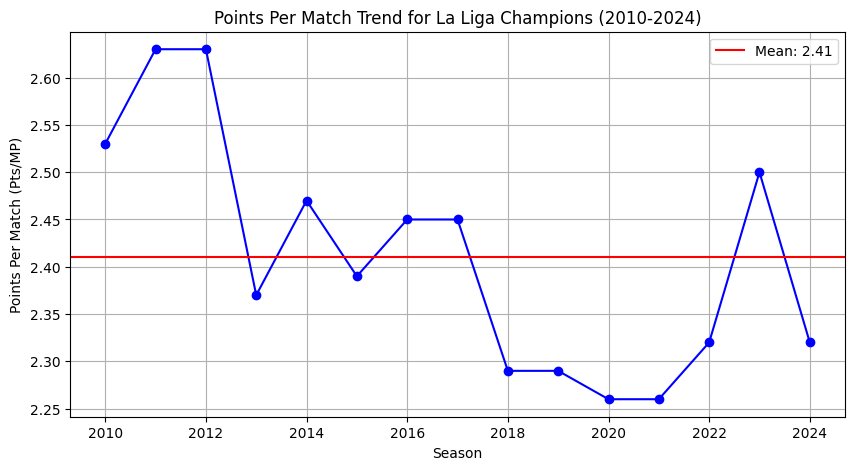

In [108]:
import matplotlib.pyplot as plt

# Plot trend of points per match (pts/mp) for champions by season
plt.figure(figsize=(10, 5))
plt.plot(champions_only["season"], champions_only["pts/mp"],
         marker="o", linestyle="-", color="b")
plt.axhline(y=mean_pts_mp, color='r', linestyle='-',
            label=f"Mean: {mean_pts_mp:.2f}")
plt.xlabel("Season")
plt.ylabel("Points Per Match (Pts/MP)")
plt.title("Points Per Match Trend for La Liga Champions (2010-2024)")
plt.grid(True)
plt.legend()
plt.show()

## Machine Learning Modeling & Predictions

In [109]:
# Libraries
from sklearn.ensemble import RandomForestClassifier  # Machine Learning Model
from sklearn.preprocessing import StandardScaler  # To normalize our features
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss  # Model Evaluation
from sklearn.model_selection import cross_val_score  # For cross-validation

import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations

In [110]:
# Create projected points feature (total points = points per match × matches played)
full_data["projected_pts"] = full_data["pts/mp"] * full_data["mp"]

In [111]:
features = ["pts/mp", "gd", "w", "l", "projected_pts"]

# Training on past seasons
df_train = full_data[full_data["season"] < 2024]
X_train = df_train[features]
y_train = df_train["is_champion"]

# Testing on 2024–25 season
df_test = full_data[full_data["season"] == 2024].copy()
X_test = df_test[features]

# Train model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predict current-season probabilities
df_test['current_prob'] = model.predict_proba(X_test)[:, 1]

In [112]:
# Calculate how many games each team has left to play (La Liga has 38 total games)
full_data["games_left"] = 38 - full_data["mp"]

# Estimate the final number of points if each team keeps their current pace
full_data["projected_pts"] = full_data["pts"] + full_data["games_left"] * full_data["pts/mp"]

# Create a binary column to indicate if a team was champion that season (1 = champion, 0 = not)
full_data["is_champion"] = (full_data["rk"] == 1).astype(int)

In [113]:
# Define the features (inputs) the model will use
features = ["pts/mp", "gd", "w", "l", "projected_pts"]

# Create training data: all seasons before 2024
df_train = full_data[full_data["season"] < 2024]

# Create testing data: only the 2024 season (current one)
df_test = full_data[full_data["season"] == 2024].copy()

# Define feature matrix (X) and target variable (y)
X_train = df_train[features]
y_train = df_train["is_champion"]
X_test = df_test[features]

In [114]:
# Initialize the model with 200 trees and a fixed random state for reproducibility
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
# Predict binary outcomes (0 or 1) on training set
train_preds = model.predict(X_train)

# Predict probabilities of being champion
train_probs = model.predict_proba(X_train)[:, 1]  # Only the prob of class 1

In [116]:
# Compute accuracy
accuracy = accuracy_score(y_train, train_preds)

# Compute ROC AUC score
roc_auc = roc_auc_score(y_train, train_probs)

# Compute log loss (lower is better)
logloss = log_loss(y_train, train_probs)

# Print performance metrics
print(f"\nModel Performance on Historical Data")
print(f"Accuracy: {accuracy:.3f}")
print(f"ROC AUC Score: {roc_auc:.3f}")
print(f"Log Loss: {logloss:.3f}")

# Print detailed classification performance
print("\nClassification Report:")
print(classification_report(y_train, train_preds))

# Show confusion matrix (true vs predicted values)
print("Confusion Matrix:")
print(confusion_matrix(y_train, train_preds))


Model Performance on Historical Data
Accuracy: 1.000
ROC AUC Score: 1.000
Log Loss: 0.012

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       266
           1       1.00      1.00      1.00        14

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280

Confusion Matrix:
[[266   0]
 [  0  14]]


In [117]:
# Predict probability of becoming champion
df_test["win_probability"] = model.predict_proba(X_test)[:, 1]

In [118]:
df_test.head()

,rk,squad,mp,w,d,l,gf,ga,gd,pts,...,notes,season,xg,xga,xgd,xgd/90,games_left,projected_pts,is_champion,win_probability
280,1,Barcelona,38,28,4,6,102,39,63,88,...,→ Champions League via league finish,2024,91.5,41.9,49.5,1.30,0,88.0,1,0.375
281,2,Real Madrid,38,26,6,6,78,38,40,84,...,→ Champions League via league finish,2024,75.3,42.8,32.5,0.86,0,84.0,0,0.060
282,3,Atlético Madrid,38,22,10,6,68,30,38,76,...,→ Champions League via league finish,2024,64.6,33.4,31.2,0.82,0,76.0,0,0.000
283,4,Athletic Club,38,19,13,6,54,29,25,70,...,→ Champions League via league finish,2024,53.0,37.8,15.2,0.40,0,70.0,0,0.000
284,5,Villarreal,38,20,10,8,71,51,20,70,...,→ Champions League via league finish,2024,64.8,44.4,20.4,0.54,0,70.0,0,0.000


In [119]:
combined_prob = 0.7 * df_test['win_probability'] + 0.3 * df_test['squad'].map(historical_weight)

In [120]:
df_test['combined_win_prob (%)'] = combined_prob / combined_prob.sum() * 100

In [121]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Generate the current season probabilities
df_test["current_prob"] = model.predict_proba(X_test)[:, 1]

In [122]:
# Map historical weight to the current season teams
df_test['historical_weight'] = df_test['squad'].map(historical_weight).fillna(0)

# Combine: 70% current season, 30% historical weight (you can adjust)
df_test['combined_prob'] = 0.7 * df_test['current_prob'] + 0.3 * df_test['historical_weight']

# Normalize to sum to 100%
df_test['combined_prob (%)'] = df_test['combined_prob'] / df_test['combined_prob'].sum() * 100

# Round for readability
df_test['combined_prob (%)'] = df_test['combined_prob (%)'].round(3)

In [ ]:
# Normalize the probabilities so that all teams add up to 100%
df_test["win_probability (%)"] = df_test["win_probability"] / df_test["win_probability"].sum() * 100

# Round the values for better readability
df_test["win_probability (%)"] = df_test["win_probability (%)"].round(3)

In [131]:
# Sort by combined probability
df_test = df_test.sort_values('combined_prob (%)', ascending=False)

# Display
df_test[['squad', 'pts', 'projected_pts', 'pts/mp',
         'gd', 'games_left', 'combined_prob (%)']]

KeyError: 'combined_prob (%)'

In [123]:
# Calculate how many games each team has left to play (La Liga has 38 total games)
full_data["games_left"] = 38 - full_data["mp"]

# Estimate the final number of points if each team keeps their current pace
full_data["projected_pts"] = full_data["pts"] + full_data["games_left"] * full_data["pts/mp"]

# Create a binary column to indicate if a team was champion that season (1 = champion, 0 = not)
full_data["is_champion"] = (full_data["rk"] == 1).astype(int)

In [125]:
# Initialize Random Forest model with 200 trees and a fixed random state for reproducibility
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Fix/Train the model on the training data
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
# Predict binary outcomes (0 or 1) on the training set
train_preds = model.predict(X_train)

# Predict probability of being champion (class 1) on the training set
train_probs = model.predict_proba(X_train)[:, 1]

In [127]:
# The following code evaluates and displays model performance on the training set

# Compute model accuracy
accuracy = accuracy_score(y_train, train_preds)

# Compute ROC AUC score
roc_auc = roc_auc_score(y_train, train_probs)

# Compute log loss (lower is better)
logloss = log_loss(y_train, train_probs)

# Print overall model performance
print(f"\nModel Performance on Historical Data")
print(f"Accuracy: {accuracy:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")
print(f"Log Loss: {logloss:.3f}")

# Print detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_train, train_preds))

# Display confusion matrix (true vs predicted values)
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, train_preds))


Model Performance on Historical Data
Accuracy: 1.000
ROC AUC: 1.000
Log Loss: 0.012

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       266
           1       1.00      1.00      1.00        14

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280


Confusion Matrix:
[[266   0]
 [  0  14]]


Definitions:

• Precision: Of all instances predicted as positive (class 1), how many were actually positive?
    Class 1 (champions): precision = 1.00 → every team predicted as champion was indeed a champion.

• Recall: Of all actual positive instances, how many did the model correctly identify?
    Class 1: recall = 1.00 → the model correctly identified all actual champions.

• F1-Score: Harmonic mean of precision and recall; balances the two metrics.
    F1 = 1.00 → perfect balance; the model is both precise and recalls all positives.

• Support: Number of actual instances of that class in the dataset.
    Class 0 (not champions): support = 266
    Class 1 (champions): support = 14

• Confusion Matrix: Shows actual vs predicted class counts.
    266 → correctly predicted non-champions
    0 → non-champions wrongly predicted as champions
    0 → champions wrongly predicted as non-champions
    14 → correctly predicted champions

In [128]:
# Predict probability of each team winning the championship
df_test["win_probability"] = model.predict_proba(X_test)[:, 1]

In [132]:
df_test.head(20)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,...,season,xg,xga,xgd,xgd/90,games_left,projected_pts,is_champion,win_probability,win_probability (%)
280,1,Barcelona,38,28,4,6,102,39,63,88,...,2024,91.5,41.9,49.5,1.30,0,88.0,1,0.375,86.207
281,2,Real Madrid,38,26,6,6,78,38,40,84,...,2024,75.3,42.8,32.5,0.86,0,84.0,0,0.060,13.793
282,3,Atlético Madrid,38,22,10,6,68,30,38,76,...,2024,64.6,33.4,31.2,0.82,0,76.0,0,0.000,0.000
283,4,Athletic Club,38,19,13,6,54,29,25,70,...,2024,53.0,37.8,15.2,0.40,0,70.0,0,0.000,0.000
284,5,Villarreal,38,20,10,8,71,51,20,70,...,2024,64.8,44.4,20.4,0.54,0,70.0,0,0.000,0.000
285,6,Betis,38,16,12,10,57,50,7,60,...,2024,54.7,50.6,4.1,0.11,0,60.0,0,0.000,0.000
286,7,Celta Vigo,38,16,7,15,59,57,2,55,...,2024,54.2,43.4,10.9,0.29,0,55.0,0,0.000,0.000
287,8,Rayo Vallecano,38,13,13,12,41,45,-4,52,...,2024,45.4,49.0,-3.5,-0.09,0,52.0,0,0.000,0.000
288,9,Osasuna,38,12,16,10,48,52,-4,52,...,2024,44.0,53.7,-9.7,-0.25,0,52.0,0,0.000,0.000
289,10,Mallorca,38,13,9,16,35,44,-9,48,...,2024,38.8,46.8,-8.1,-0.21,0,48.0,0,0.000,0.000


In [133]:
combined_prob = 0.7 * df_test['win_probability'] + 0.3 * df_test['squad'].map(historical_weight)

In [134]:
df_test['combined_win_prob (%)'] = combined_prob / combined_prob.sum() * 100

In [135]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Generate the current season probabilities
df_test["current_prob"] = model.predict_proba(X_test)[:, 1]

In [ ]:
# Map historical weight to the current season teams
df_test['historical_weight'] = df_test['squad'].map(historical_weight).fillna(0)

# Combine: 70% current season, 30% historical weight (you can adjust)
df_test['combined_prob'] = 0.7 * df_test['current_prob'] + 0.3 * df_test['historical_weight']

# Normalize to sum to 100%
df_test['combined_prob (%)'] = df_test['combined_prob'] / df_test['combined_prob'].sum() * 100

# Round for readability
df_test['combined_prob (%)'] = df_test['combined_prob (%)'].round(3)

In [137]:
# Normalize the probabilities so that all teams add up to 100%
df_test["win_probability (%)"] = df_test["win_probability"] / df_test["win_probability"].sum() * 100

# Round the values for better readability
df_test["win_probability (%)"] = df_test["win_probability (%)"].round(3)

In [138]:
# Sort by combined probability
df_test = df_test.sort_values('combined_prob (%)', ascending=False)

# Display
df_test[['squad', 'pts', 'projected_pts', 'pts/mp',
         'gd', 'games_left', 'combined_prob (%)']]

,squad,pts,projected_pts,pts/mp,gd,games_left,combined_prob (%)
280,Barcelona,88,88.0,2.32,63,0,59.967
281,Real Madrid,84,84.0,2.21,40,0,23.490
282,Atlético Madrid,76,76.0,2.00,38,0,12.998
291,Valencia,46,46.0,1.21,-10,0,2.363
295,Girona,41,41.0,1.08,-16,0,1.182
298,Las Palmas,32,32.0,0.84,-21,0,0.000
297,Leganés,40,40.0,1.05,-17,0,0.000
296,Sevilla,41,41.0,1.08,-13,0,0.000
294,Alavés,42,42.0,1.11,-10,0,0.000
293,Espanyol,42,42.0,1.11,-11,0,0.000


In [139]:
# Sort teams by their combined win probability (highest first)
df_test_sorted = df_test.sort_values(by="combined_prob (%)", ascending=False)

# Get the top team (highest predicted probability)
predicted_winner = df_test_sorted.iloc[0]

# Print the results
print("🏆 Predicted La Liga 2025–26 Champion 🏆")
print(f"Team: {predicted_winner['squad']}")
print(f"Winning Probability: {predicted_winner['combined_prob (%)']:.2f}%")

# (Optional) Display top 5 title contenders
print("\nTop 5 Predicted Contenders:")
print(df_test_sorted[['squad', 'combined_prob (%)']].head(5))

🏆 Predicted La Liga 2025–26 Champion 🏆
Team: Barcelona
Winning Probability: 59.97%

Top 5 Predicted Contenders:
               squad  combined_prob (%)
280        Barcelona             59.967
281      Real Madrid             23.490
282  Atlético Madrid             12.998
291         Valencia              2.363
295           Girona              1.182


In [73]:
import os
import joblib

# Makes sure the folder exists
os.makedirs("champion_predictor", exist_ok=True)

# Saves trained model
joblib.dump(model, "champion_predictor/la_liga_model_predictor.pkl")
print("Model saved as champion_predictor/la_liga_model_predictor.pkl")

Model saved as champion_predictor/la_liga_model_predictor.pkl
